# 다른 구 간 이동 승차거리(5km 기준) 분석

## 목적 및 가설

서울시 장애인콜택시 요금 체계는 5km 이내 기본요금 구간이 있는 것으로 알려져 있다(공식 요금표는 이번 분석에서 별도 검증하지 않음). 이를 전제로 가설을 두 단계로 나눈다.

> **가설 1 (데이터 가설)**: 다른 구 간 이동 상위 30개 경로는 전체 다른 구 간 이동보다 5km 이내 이동 비율이 높을 것이다.
>
> **가설 2 (서비스 설계 가설)**: 상위 수요 경로에서 5km 이내 이동이 충분한 비중을 차지한다면, 5km 이내 구간 중심의 경로 안내 설계는 주요 수요를 일정 부분 포괄할 수 있다.

가설 1은 이 노트북에서 직접 검증하고, 가설 2는 가설 1의 결과를 근거로 판단하는 후속 해석이다.

**서비스 설계와의 연결**: 개발팀 논의 결과, 5km 이내 고정 기본요금으로 단순화하는 방향은 채택하지 않았다. 대신 실제로 수요가 5km 이내 이동에 많이 몰려 있다면, **경로 안내 자체를 최대 5km 범위 내로 안내하는 방향**을 검토 중이다. 결과는 "5km 이내 비율이 O%"로만 보고하지 않고, 그 이면의 **"5km를 초과해 커버되지 않는 비율"도 항상 함께 제시**한다.

이번 분석은 `02_od_flow_same_vs_diff_gu.ipynb`에서 이미 산출한 **"다른 구 간 이동 상위 30개"** 경로 정의를 그대로 재사용하고, 그동안 어떤 노트북도 다루지 않은 **`승차거리`** 컬럼을 결합해 위 가설을 검증한다.

계획 문서: `notebooks_docs_lye/260910_구간이동_승차거리_5km_분석_계획.md` (팀 리뷰 피드백 반영, 사용자 승인 완료 2026-09-10)


In [3]:
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

boarding_path = DATA_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
df.head()


c:\Users\young\my_project\260901_call_taxi_DA\data\processed\서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


In [4]:
use_cols = ["출발구", "목적구", "승차거리", "승차일시", "하차일시", "취소일시"]

missing_counts = df[use_cols].isna().sum()
print("사용 컬럼 결측치 개수")
display(missing_counts.to_frame("결측치_건수"))

print(f"\n승차거리 = 0 건수: {(df['승차거리'] == 0).sum():,}")
print(f"승차거리 < 0 건수: {(df['승차거리'] < 0).sum():,}")
print(f"승차거리 기술통계:\n{df['승차거리'].describe()}")


사용 컬럼 결측치 개수


,결측치_건수
출발구,1
목적구,1
승차거리,0
승차일시,245361
하차일시,245423
취소일시,1477193



승차거리 = 0 건수: 245,423
승차거리 < 0 건수: 0
승차거리 기술통계:
count    1.722490e+06
mean     7.332305e+03
std      9.291749e+03
min      0.000000e+00
25%      2.111000e+03
50%      4.541000e+03
75%      9.508000e+03
max      8.094630e+05
Name: 승차거리, dtype: float64


## 데이터 출처 및 단위

**메인 데이터**: `data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv` — 서울시설공단 원본을 팀이 전처리한 정제본 (`02_od_flow_same_vs_diff_gu.ipynb`, `04_inter_gu_movement_analysis.ipynb`와 동일 소스). 이 중 `출발구`, `목적구`, `승차거리`, `승차일시`, `하차일시`, `취소일시`, `요금` 컬럼을 사용한다.

**`승차거리` 단위**: 컬럼명에 단위 표기가 없으나, 중앙값(4,541m)·최댓값(809,463m) 등 값의 크기로 볼 때 **m(미터)**로 추정된다 — km라면 비현실적으로 큰 값이 된다. 이후 모든 계산은 m 단위(5km 기준 = 5,000m)로 하되, 그래프에 보이는 축·라벨은 km로 통일한다.

**`승차거리 = 0`의 의미**: 결측치는 아니지만(0건 결측), 245,423건이 정확히 0으로 기록되어 있다. 이는 뒤에서 확인하듯 탑승완료(승차·하차 기록 존재)되지 않은 건(취소 등)에서만 나타나며, 실제 탑승 후 이동거리가 0인 사례가 아니다 — 즉 결측치와 동일하게 취급해 분석 전 반드시 제외해야 한다.


In [5]:
completed = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
].copy()

print(f"탑승완료 건수: {len(completed):,} / 전체 {len(df):,} ({len(completed) / len(df) * 100:.1f}%)")


탑승완료 건수: 1,477,067 / 전체 1,722,490 (85.8%)


In [6]:
zero_distance = df[df["승차거리"] == 0]
not_completed_mask = ~(
    df["승차일시"].notna() & df["하차일시"].notna() & df["취소일시"].isna()
)
not_completed_index = set(df[not_completed_mask].index)

zero_in_not_completed = set(zero_distance.index).issubset(not_completed_index)

print(f"승차거리=0 건수: {len(zero_distance):,}")
print(f"승차거리=0 건이 전부 '탑승완료 아님'에 속하는가: {zero_in_not_completed}")

assert zero_in_not_completed, "승차거리=0 건 중 탑승완료 건이 존재함 — 0을 결측과 동일 취급하면 안 됨"
print("검증 통과 — 승차거리=0은 결측과 동일한 의미(탑승완료 아님)로 취급 가능")


승차거리=0 건수: 245,423
승차거리=0 건이 전부 '탑승완료 아님'에 속하는가: True
검증 통과 — 승차거리=0은 결측과 동일한 의미(탑승완료 아님)로 취급 가능


In [7]:
OUTLIER_THRESHOLD_M = 100_000  # 100km

before_rows = len(completed)
outliers = completed[completed["승차거리"] > OUTLIER_THRESHOLD_M]

print(f"탑승완료 기준 100km 초과 이상치: {len(outliers):,}건 ({len(outliers) / before_rows * 100:.3f}%)")
print(f"이상치 승차거리 범위: {outliers['승차거리'].min():,}m ~ {outliers['승차거리'].max():,}m")

completed = completed[completed["승차거리"] <= OUTLIER_THRESHOLD_M].copy()

after_rows = len(completed)
print(f"\n제거 전 행 수: {before_rows:,}")
print(f"제거 후 행 수: {after_rows:,}")
print(f"제거된 행 수: {before_rows - after_rows:,}")
print("\n※ 사용자 승인(2026-09-10)에 따라 100km 초과 이상치를 분석 모집단에서 제거함. 이후 모든 셀은 이 데이터를 사용.")


탑승완료 기준 100km 초과 이상치: 92건 (0.006%)
이상치 승차거리 범위: 100,158m ~ 809,463m

제거 전 행 수: 1,477,067
제거 후 행 수: 1,476,975
제거된 행 수: 92

※ 사용자 승인(2026-09-10)에 따라 100km 초과 이상치를 분석 모집단에서 제거함. 이후 모든 셀은 이 데이터를 사용.


In [8]:
SEOUL_25 = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구",
]

seoul_completed = completed[
    completed["출발구"].isin(SEOUL_25) & completed["목적구"].isin(SEOUL_25)
].copy()

print(f"탑승완료(이상치 제거) 중 서울 25구 내부 이동: {len(seoul_completed):,} / {len(completed):,} ({len(seoul_completed) / len(completed) * 100:.1f}%)")


탑승완료(이상치 제거) 중 서울 25구 내부 이동: 1,362,621 / 1,476,975 (92.3%)


In [9]:
diff_gu = seoul_completed[seoul_completed["출발구"] != seoul_completed["목적구"]].copy()

print(f"다른 구 간 이동: {len(diff_gu):,}건")

diff_gu_rank = (
    diff_gu.groupby(["출발구", "목적구"])
    .size()
    .reset_index(name="이동건수")
    .sort_values("이동건수", ascending=False)
    .reset_index(drop=True)
)
diff_gu_rank["경로"] = diff_gu_rank["출발구"] + " → " + diff_gu_rank["목적구"]
diff_gu_rank["순위"] = diff_gu_rank.index + 1

top30 = diff_gu_rank.head(30).copy()
print(f"\nTop 30 경로 (건수 상위):")
display(top30[["순위", "경로", "이동건수"]])


다른 구 간 이동: 836,535건

Top 30 경로 (건수 상위):


,순위,경로,이동건수
0,1,서대문구 → 마포구,15727
1,2,마포구 → 서대문구,15351
2,3,노원구 → 도봉구,13931
3,4,도봉구 → 노원구,13072
4,5,마포구 → 은평구,12223
5,6,서대문구 → 은평구,11319
6,7,은평구 → 서대문구,11089
7,8,은평구 → 마포구,9956
8,9,노원구 → 중랑구,9477
9,10,송파구 → 강동구,9061


In [10]:
# 02_od_flow_same_vs_diff_gu.ipynb는 100km 초과 이상치를 제거하지 않으므로,
# 동일 조건(이상치 미제거)으로 Top 30을 재계산해 이번 노트북의 Top 30과 비교한다.
seoul_completed_no_outlier_removal = df[
    df["승차일시"].notna()
    & df["하차일시"].notna()
    & df["취소일시"].isna()
]
seoul_completed_no_outlier_removal = seoul_completed_no_outlier_removal[
    seoul_completed_no_outlier_removal["출발구"].isin(SEOUL_25)
    & seoul_completed_no_outlier_removal["목적구"].isin(SEOUL_25)
]
diff_gu_02 = seoul_completed_no_outlier_removal[
    seoul_completed_no_outlier_removal["출발구"] != seoul_completed_no_outlier_removal["목적구"]
]
diff_gu_rank_02 = (
    diff_gu_02.groupby(["출발구", "목적구"])
    .size()
    .reset_index(name="이동건수")
    .sort_values("이동건수", ascending=False)
    .reset_index(drop=True)
)
top30_02 = diff_gu_rank_02.head(30)[["출발구", "목적구"]].reset_index(drop=True)
top30_this = top30[["출발구", "목적구"]].reset_index(drop=True)

same_list = top30_02.equals(top30_this)
print(f"02(이상치 미제거 기준) Top 30과 이번 분석(이상치 제거 후) Top 30이 순서·구성 모두 동일한가: {same_list}")

if not same_list:
    diff_rows = pd.concat([top30_02, top30_this]).drop_duplicates(keep=False)
    print("차이 발생 행:")
    display(diff_rows)
else:
    print("→ 100km 초과 이상치(0.006%)는 Top 30 순위에 영향을 주지 않음을 확인. 02의 Top 30 정의를 그대로 재사용 가능.")


02(이상치 미제거 기준) Top 30과 이번 분석(이상치 제거 후) Top 30이 순서·구성 모두 동일한가: True
→ 100km 초과 이상치(0.006%)는 Top 30 순위에 영향을 주지 않음을 확인. 02의 Top 30 정의를 그대로 재사용 가능.


In [11]:
diff_gu["5km이내"] = diff_gu["승차거리"] <= 5000
diff_gu["5km초과"] = ~diff_gu["5km이내"]

bins_m = [0, 1000, 2000, 3000, 4000, 5000, 10000, 20000, float("inf")]
band_labels = ["0~1km", "1~2km", "2~3km", "3~4km", "4~5km", "5~10km", "10~20km", "20km+"]
diff_gu["거리구간"] = pd.cut(
    diff_gu["승차거리"], bins=bins_m, labels=band_labels, right=True, include_lowest=True
)

diff_gu = diff_gu.merge(
    top30[["출발구", "목적구"]].assign(Top30여부=True),
    on=["출발구", "목적구"],
    how="left",
)
diff_gu["Top30여부"] = diff_gu["Top30여부"].fillna(False).infer_objects(copy=False)

print(diff_gu[["승차거리", "5km이내", "5km초과", "거리구간", "Top30여부"]].head())


    승차거리  5km이내  5km초과     거리구간  Top30여부
0  17667  False   True  10~20km    False
1  10421  False   True  10~20km    False
2  11943  False   True  10~20km    False
3  13704  False   True  10~20km    False
4   8799  False   True   5~10km    False


C:\Users\young\AppData\Local\Temp\ipykernel_21212\217829713.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  diff_gu["Top30여부"] = diff_gu["Top30여부"].fillna(False).infer_objects(copy=False)


In [12]:
baseline_ratio = diff_gu["5km이내"].mean()
baseline_n = len(diff_gu)

print(f"baseline(다른구 이동 전체, 이상치 제거 후) 5km 이내 비율: {baseline_ratio * 100:.1f}% (n={baseline_n:,})")
print(f"baseline 5km 초과 비율: {(1 - baseline_ratio) * 100:.1f}%")
print("\n※ 계획 문서(§3-1)의 예비 확인치 46.4%는 '탑승완료 전체'(같은구+다른구 포함) 기준이었다.")
print("   이번 분석의 실제 baseline은 '다른구 이동'만 대상으로 하므로 값이 다르게 나온다 — 같은구 이동은 대체로 훨씬 짧아 baseline을 높이는 방향으로 작용했었다.")


baseline(다른구 이동 전체, 이상치 제거 후) 5km 이내 비율: 25.2% (n=836,535)
baseline 5km 초과 비율: 74.8%

※ 계획 문서(§3-1)의 예비 확인치 46.4%는 '탑승완료 전체'(같은구+다른구 포함) 기준이었다.
   이번 분석의 실제 baseline은 '다른구 이동'만 대상으로 하므로 값이 다르게 나온다 — 같은구 이동은 대체로 훨씬 짧아 baseline을 높이는 방향으로 작용했었다.


In [13]:
route_stats = (
    diff_gu[diff_gu["Top30여부"]]
    .groupby(["출발구", "목적구"])
    .agg(
        이동건수=("5km이내", "size"),
        **{"5km이내건수": ("5km이내", "sum")},
    )
    .reset_index()
)
route_stats["5km이내비율"] = route_stats["5km이내건수"] / route_stats["이동건수"]
route_stats["5km초과비율"] = 1 - route_stats["5km이내비율"]
route_stats["5km초과건수"] = route_stats["이동건수"] - route_stats["5km이내건수"]
route_stats["경로"] = route_stats["출발구"] + " → " + route_stats["목적구"]

route_stats = route_stats.merge(top30[["출발구", "목적구", "순위"]], on=["출발구", "목적구"], how="left")
route_stats = route_stats.sort_values("5km이내비율", ascending=False).reset_index(drop=True)

print(f"Top 30 경로별 5km 이내 비율 (범위: {route_stats['5km이내비율'].min()*100:.1f}% ~ {route_stats['5km이내비율'].max()*100:.1f}%)")
display(route_stats[["순위", "경로", "이동건수", "5km이내건수", "5km이내비율", "5km초과비율"]])


Top 30 경로별 5km 이내 비율 (범위: 1.3% ~ 79.8%)


,순위,경로,이동건수,5km이내건수,5km이내비율,5km초과비율
0,11,관악구 → 동작구,8987,7170,0.797819,0.202181
1,1,서대문구 → 마포구,15727,11664,0.741654,0.258346
2,16,동작구 → 관악구,8547,6328,0.740377,0.259623
3,2,마포구 → 서대문구,15351,10916,0.711094,0.288906
4,4,도봉구 → 노원구,13072,8952,0.684823,0.315177
5,3,노원구 → 도봉구,13931,9424,0.676477,0.323523
6,30,성북구 → 강북구,5623,3556,0.632403,0.367597
7,29,구로구 → 양천구,5733,3420,0.596546,0.403454
8,21,구로구 → 영등포구,7015,3490,0.497505,0.502495
9,24,영등포구 → 구로구,6611,3271,0.494781,0.505219


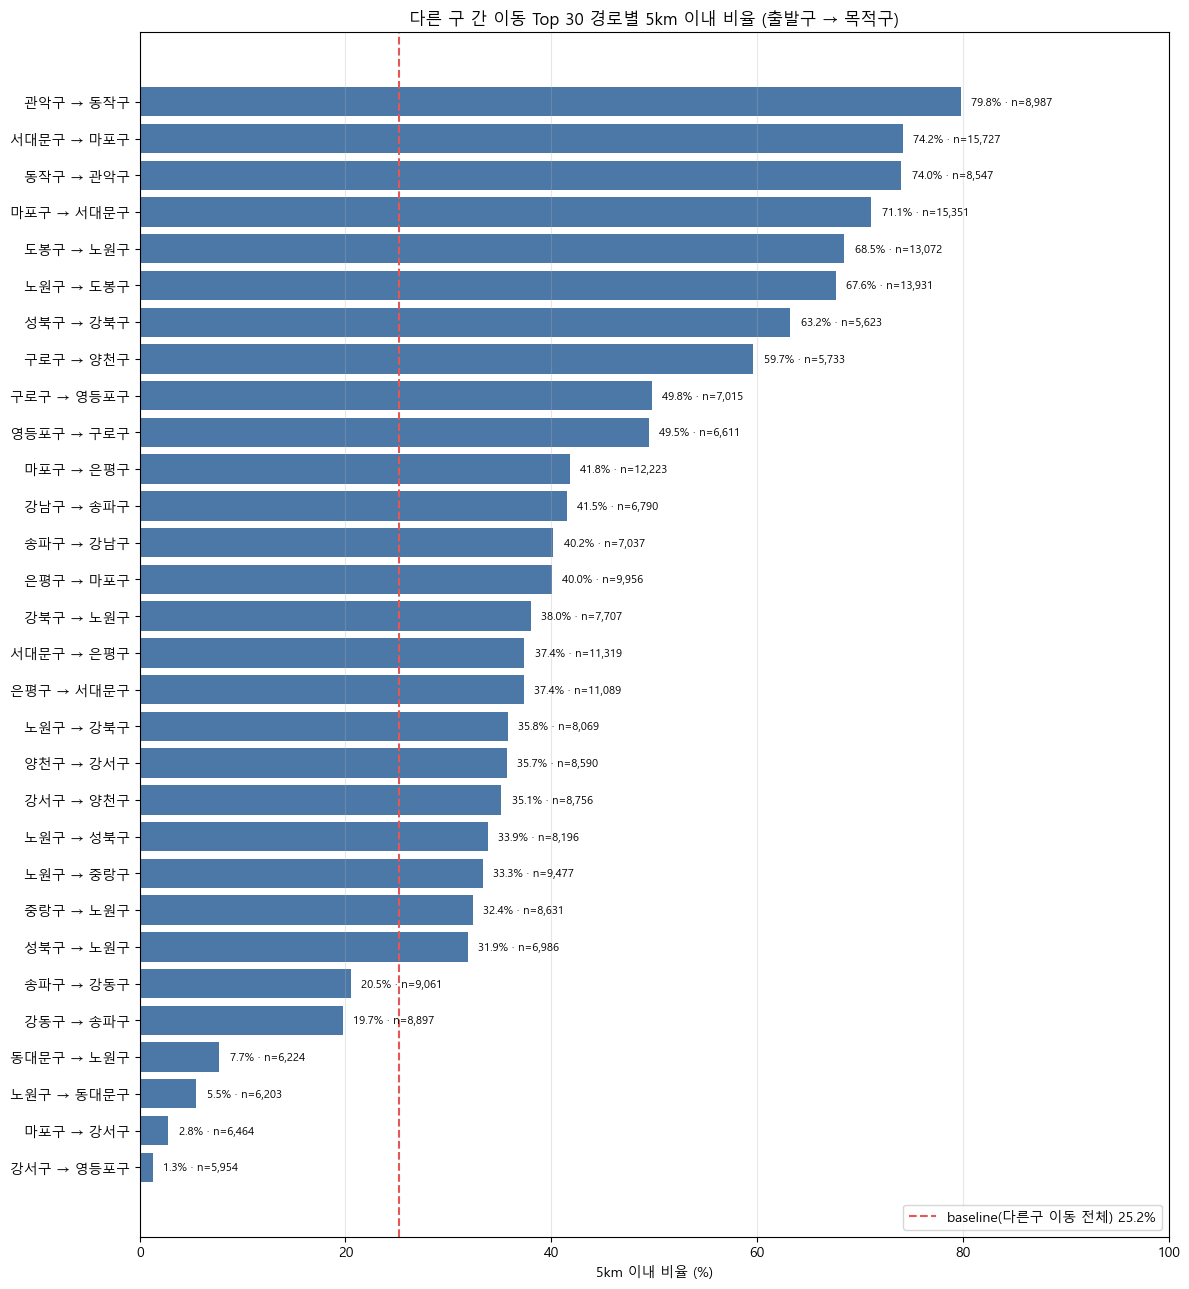

In [14]:
plot_data = route_stats.sort_values("5km이내비율", ascending=True).copy()
plot_data["라벨"] = plot_data.apply(
    lambda r: f"{r['5km이내비율']*100:.1f}% · n={r['이동건수']:,}", axis=1
)

fig, ax = plt.subplots(figsize=(12, 13))
ax.barh(plot_data["경로"], plot_data["5km이내비율"] * 100, color="#4c78a8")

ax.axvline(baseline_ratio * 100, color="#e45756", linestyle="--", linewidth=1.5,
           label=f"baseline(다른구 이동 전체) {baseline_ratio*100:.1f}%")

for i, (value, label) in enumerate(zip(plot_data["5km이내비율"] * 100, plot_data["라벨"])):
    ax.text(value + 1, i, label, va="center", fontsize=8)

ax.set_xlim(0, 100)
ax.set_xlabel("5km 이내 비율 (%)")
ax.set_title("다른 구 간 이동 Top 30 경로별 5km 이내 비율 (출발구 → 목적구)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_top30_5km_ratio.png", dpi=120)
plt.show()


In [15]:
top30_trips = diff_gu[diff_gu["Top30여부"]]
rest_trips = diff_gu[~diff_gu["Top30여부"]]

summary_rows = []
for name, group in [("Top 30", top30_trips), ("나머지", rest_trips)]:
    n = len(group)
    within = group["5km이내"].mean()
    summary_rows.append({
        "구분": name,
        "건수": n,
        "전체 대비 비중(%)": n / len(diff_gu) * 100,
        "5km이내비율(%)": within * 100,
        "5km초과비율(%)": (1 - within) * 100,
    })

group_summary = pd.DataFrame(summary_rows)
display(group_summary)


,구분,건수,전체 대비 비중(%),5km이내비율(%),5km초과비율(%)
0,Top 30,268226,32.06393,44.335747,55.664253
1,나머지,568309,67.93607,16.210899,83.789101


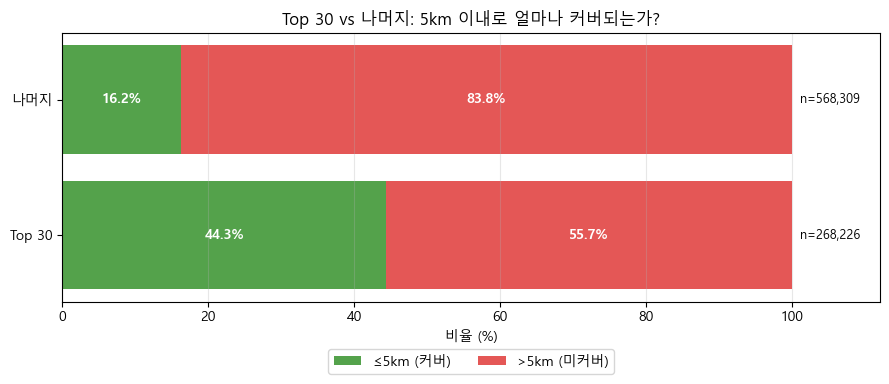

In [16]:
categories = group_summary["구분"].tolist()
within_pct = group_summary["5km이내비율(%)"].tolist()
over_pct = group_summary["5km초과비율(%)"].tolist()
counts = group_summary["건수"].tolist()

fig, ax = plt.subplots(figsize=(9, 4))

bars_within = ax.barh(categories, within_pct, color="#54a24b", label="≤5km (커버)")
bars_over = ax.barh(categories, over_pct, left=within_pct, color="#e45756", label=">5km (미커버)")

for i, (w, o, n) in enumerate(zip(within_pct, over_pct, counts)):
    ax.text(w / 2, i, f"{w:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(w + o / 2, i, f"{o:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    ax.text(101, i, f"n={n:,}", va="center", fontsize=9)

ax.set_xlim(0, 112)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xlabel("비율 (%)")
ax.set_title("Top 30 vs 나머지: 5km 이내로 얼마나 커버되는가?")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_top30_vs_rest_stacked.png", dpi=120)
plt.show()


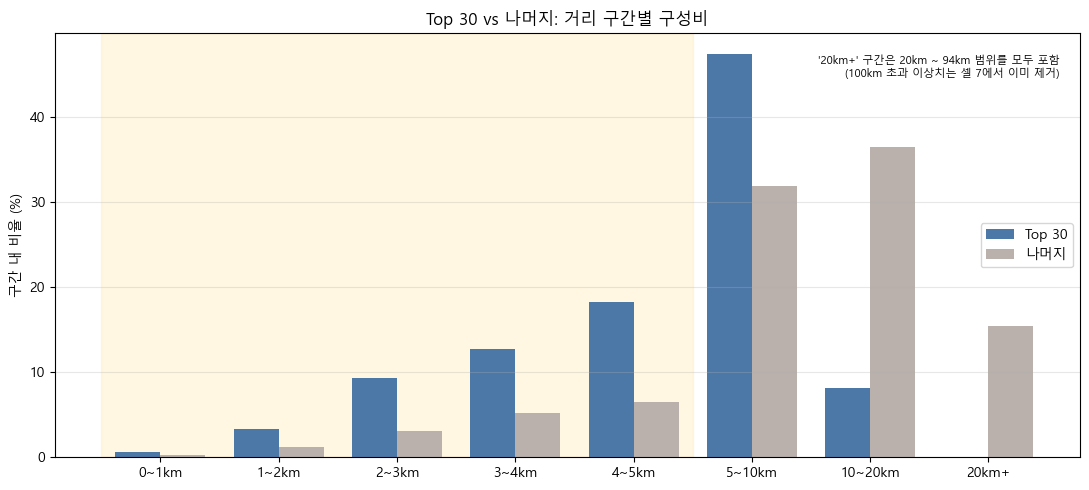

In [17]:
band_top30 = (
    top30_trips["거리구간"].value_counts(normalize=True).reindex(band_labels).fillna(0) * 100
)
band_rest = (
    rest_trips["거리구간"].value_counts(normalize=True).reindex(band_labels).fillna(0) * 100
)

x = np.arange(len(band_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, band_top30.values, width, label="Top 30", color="#4c78a8")
ax.bar(x + width / 2, band_rest.values, width, label="나머지", color="#bab0ac")

ax.axvspan(-0.5, 4.5, color="#ffe08a", alpha=0.25, zorder=0)  # 0~5km 구간 강조(0~1~..~4~5km, 인덱스 0~4)

ax.set_xticks(x)
ax.set_xticklabels(band_labels)
ax.set_ylabel("구간 내 비율 (%)")
ax.set_title("Top 30 vs 나머지: 거리 구간별 구성비")
ax.legend()
ax.grid(axis="y", alpha=0.3)

max_20km_plus = diff_gu["승차거리"].max() / 1000
ax.annotate(
    f"'20km+' 구간은 20km ~ {max_20km_plus:.0f}km 범위를 모두 포함\n(100km 초과 이상치는 셀 7에서 이미 제거)",
    xy=(0.98, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=8,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_distance_band_composition.png", dpi=120)
plt.show()


## 가설 1 해석

- baseline(다른구 이동 전체) 5km 이내 비율은 **약 25.2%**인 반면, **Top 30 경로 통합은 약 44.3%**로 baseline보다 확연히 높다. 반대로 **나머지 경로는 약 16.2%**로 baseline보다 낮다 — Top 30(전체 다른구 이동 건수의 32.1%)이 상대적으로 짧은 이동에 몰려 있다는 **가설 1은 채택**된다. (정확한 수치는 위 셀 12·15 실행 결과 참고 — 아래는 실행 시점 기준 근사치)
- 다만 Top 30 안에서도 편차가 크다. 5km 이내 비율이 가장 높은 경로(관악구 → 동작구 등)는 약 80%에 달하지만, 가장 낮은 경로(강서구 → 영등포구 등)는 약 1%대에 불과하다 — "Top 30이라서 무조건 짧다"가 아니라 **일부 경로가 이 패턴을 강하게 주도**하고 있다.
- 가장 중요한 것은 **Top 30조차 5km 초과 비율이 약 55.7%로 과반**이라는 점이다 — 즉 가장 수요가 많은 경로들만 놓고 봐도, 5km 이내 안내만으로는 절반 이상의 이동을 커버하지 못한다.


In [18]:
within5 = diff_gu[diff_gu["5km이내"]]
print(f"5km 이내 트립 수: {len(within5):,}")
print(f"요금 결측: {within5['요금'].isna().sum():,} / {len(within5):,}")

fare_freq = (
    within5["요금"].value_counts(dropna=True)
    .reset_index()
)
fare_freq.columns = ["요금", "건수"]
fare_freq["비율(%)"] = fare_freq["건수"] / fare_freq["건수"].sum() * 100
fare_freq = fare_freq.sort_values("건수", ascending=False).reset_index(drop=True)

print(f"\n5km 이내 구간에서 가장 빈번한 요금 상위 10개:")
display(fare_freq.head(10))


5km 이내 트립 수: 211,048
요금 결측: 0 / 211,048

5km 이내 구간에서 가장 빈번한 요금 상위 10개:


,요금,건수,비율(%)
0,1500.0,210902,99.930821
1,1700.0,76,0.036011
2,45000.0,67,0.031746
3,46000.0,1,0.000474
4,47900.0,1,0.000474
5,45200.0,1,0.000474


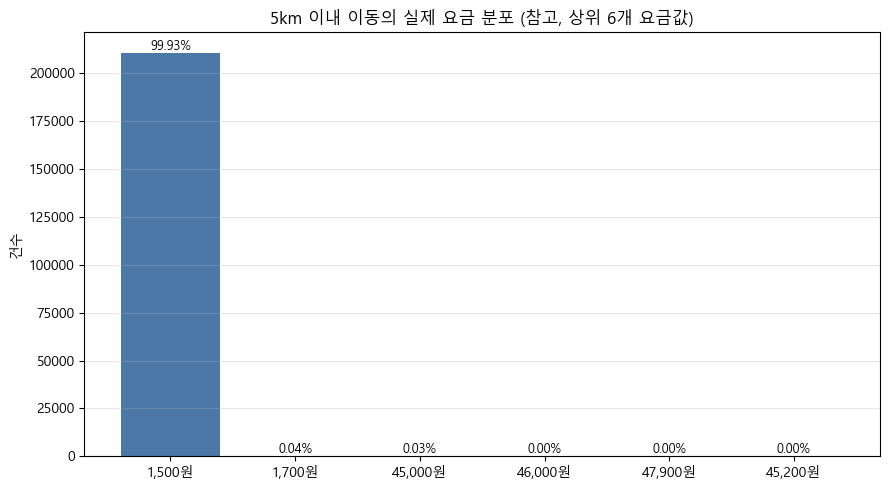

In [19]:
top_fares = fare_freq.head(6).copy()
top_fares["요금_라벨"] = top_fares["요금"].apply(lambda v: f"{v:,.0f}원")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(top_fares["요금_라벨"], top_fares["건수"], color="#4c78a8")

for bar, pct in zip(bars, top_fares["비율(%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.2f}%",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("건수")
ax.set_title("5km 이내 이동의 실제 요금 분포 (참고, 상위 6개 요금값)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_fare_frequency_within5km.png", dpi=120)
plt.show()


## 보조 검증(요금) 해석

5km 이내 이동의 요금은 특정 값(약 1,500원)에 **약 99.9%**가 몰려 있다 — 이는 5km 이내가 실제로 좁은 요금 구간으로 수렴함을 데이터로 보여준다(정확한 수치는 위 셀 19 실행 결과 참고). 다만 이것이 "5km 기본요금 정책이 검증됐다"는 의미는 아니다 — 공식 요금표를 대조한 것이 아니라, 이번 데이터에서 관찰된 요금 분포를 참고로 확인한 것이다. 소수의 이상 요금(4만 원대 등)은 별도 조사가 필요한 데이터 이슈로 남겨둔다.


In [20]:
result_to_save = route_stats[[
    "출발구", "목적구", "경로", "순위", "이동건수", "5km이내건수", "5km이내비율", "5km초과건수", "5km초과비율",
]].sort_values("순위").reset_index(drop=True)

# 저장 전 assert: 02 Top30 리스트와 (출발구,목적구) 순서·건수 일치 확인
assert same_list, "이번 Top30이 02의 Top30과 다름 — 저장 전 반드시 원인 확인 필요"
assert len(result_to_save) == 30, "Top 30 저장 결과가 30건이 아님"

save_path = DATA_DIR / "region_top30_diff_gu_route_distance_20251231.csv"
result_to_save.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {save_path}")
display(result_to_save.head())


저장 완료: c:\Users\young\my_project\260901_call_taxi_DA\data\processed\region_top30_diff_gu_route_distance_20251231.csv


,출발구,목적구,경로,순위,이동건수,5km이내건수,5km이내비율,5km초과건수,5km초과비율
0,서대문구,마포구,서대문구 → 마포구,1,15727,11664,0.741654,4063,0.258346
1,마포구,서대문구,마포구 → 서대문구,2,15351,10916,0.711094,4435,0.288906
2,노원구,도봉구,노원구 → 도봉구,3,13931,9424,0.676477,4507,0.323523
3,도봉구,노원구,도봉구 → 노원구,4,13072,8952,0.684823,4120,0.315177
4,마포구,은평구,마포구 → 은평구,5,12223,5113,0.418310,7110,0.581690


## 종합 인사이트

**가설 1 (데이터 가설) — 채택**: 다른 구 간 이동 상위 30개 경로(전체 다른구 이동의 32.1%)는 baseline(25.2%) 대비 5km 이내 비율이 뚜렷하게 높다(44.3% vs 25.2%). 반면 나머지 경로는 baseline보다 낮다(16.2%). Top 30 안에서도 경로별 편차가 매우 커서(1%대 ~ 80%대), 일부 경로가 이 패턴을 주도하고 있다는 점도 함께 확인했다.

**가설 2 (서비스 설계 가설) — 제한적으로만 지지**: "5km 이내 경로 안내"가 수요가 많은 Top 30 경로에서는 나머지보다 상대적으로 더 많은 수요를 커버하는 것은 맞다. 하지만 Top 30조차 5km 초과 비율이 55.7%로 과반이다 — 즉 **가장 수요가 많은 경로들만 골라도 5km 제한 안내는 절반 이상의 이동을 놓친다.** 따라서 "5km 이내 우선 안내 + 5km 초과 시 별도 안내/유의 문구"처럼, 5km를 완전한 컷오프가 아니라 **1차 필터/우선순위** 정도로 활용하는 설계가 더 현실적일 수 있다는 시사점을 준다.

**한계**:
- 100km 초과 이상치(92건, 0.006%)는 제거했지만, 5~100km 사이의 나머지 장거리 이동은 그대로 포함돼 있다.
- baseline은 "다른구 이동 전체" 기준이며, 계획 문서(§3-1)의 예비 확인치(46.4%, 탑승완료 전체 기준)와는 값이 다르다 — 같은구 이동이 baseline에서 빠지면서 값이 낮아졌다(46.4% → 25.2%).
- 요금 보조 검증은 공식 요금표 대조가 아닌 참고 지표다.

**후속 과제**: 목적구 단위/시간대별로 5km 이내 비율이 달라지는지, 차량구분(특장차/임차택시)별로도 차이가 있는지는 이번 범위 밖이며 향후 분석 후보로 남긴다.
